# ☕ Аналитика кофейного автомата | Business Dashboard
> Анализ транзакций за 2024–2025 год. Цель - найти точки роста, понять поведение клиентов и оптимизировать работу автомата.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

#  палитра 
BG       = '#1C0F08'   # espresso 
PANEL    = '#2A1508'   # dark roast 
GRID     = '#4A2E1A'   # medium roast
TEXT     = '#F5E6D3'   # сливки 
ACCENT   = '#D4874E'   # карамель 
ACCENT2  = '#F2C882'   # honey latte 
ACCENT3  = '#C67B3C'   # cinnamon 
ACCENT4  = '#8B5E3C'   # mocha 
ACCENT5  = '#E8A87C'   # latte
PALETTE  = [ACCENT, ACCENT2, ACCENT3, ACCENT5, '#F0D080',
            '#B87333', '#DEB887', '#CD853F']

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    PANEL,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   TEXT,
    'axes.titlecolor':   TEXT,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.grid':         True,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'font.family':       'DejaVu Sans',
    'legend.facecolor':  PANEL,
    'legend.edgecolor':  GRID,
    'legend.labelcolor': TEXT,
    'figure.dpi':        110,
})

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_title(title)
    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.spines[['top','right','left','bottom']].set_color(GRID)
    return ax

print('настройки готовы')


настройки готовы


## 📥 Загрузка и подготовка данных

In [4]:
PATH_2024 = '/Users/aomine/Desktop/coffee/index_1.csv'
PATH_2025 = '/Users/aomine/Desktop/coffee/index_2.csv'
df24 = pd.read_csv(PATH_2024)
df25 = pd.read_csv(PATH_2025)

df = pd.concat([df24, df25], ignore_index=True)

# даты
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
df['date']     = pd.to_datetime(df['date'],     errors='coerce')
df = df.dropna(subset=['datetime'])

# Фичи времени
df['hour']       = df['datetime'].dt.hour
df['weekday']    = df['datetime'].dt.day_name()
df['weekday_n']  = df['datetime'].dt.dayofweek
df['month']      = df['datetime'].dt.to_period('M').astype(str)
df['week']       = df['datetime'].dt.to_period('W').astype(str)
df['year']       = df['datetime'].dt.year

# названия напитков
df['coffee_name'] = df['coffee_name'].str.strip()

print(f'   Всего транзакций: {len(df):,}')
print(f'   Период: {df["datetime"].min().date()} → {df["datetime"].max().date()}')
print(f'   Напитков: {df["coffee_name"].nunique()}')
print(f'   Общая выручка: {df["money"].sum():,.1f} грн')
print(f'\n{df.head(3)}')

   Всего транзакций: 3,636
   Период: 2024-03-01 → 2025-03-23
   Напитков: 8
   Общая выручка: 115,431.6 грн

        date                datetime cash_type                 card  money  \
0 2024-03-01 2024-03-01 10:15:50.520      card  ANON-0000-0000-0001   38.7   
1 2024-03-01 2024-03-01 12:19:22.539      card  ANON-0000-0000-0002   38.7   
2 2024-03-01 2024-03-01 12:20:18.089      card  ANON-0000-0000-0002   38.7   

     coffee_name  hour weekday  weekday_n    month                   week  \
0          Latte    10  Friday          4  2024-03  2024-02-26/2024-03-03   
1  Hot Chocolate    12  Friday          4  2024-03  2024-02-26/2024-03-03   
2  Hot Chocolate    12  Friday          4  2024-03  2024-02-26/2024-03-03   

   year  
0  2024  
1  2024  
2  2024  


## 📊 1. KPI: ключевые метрики бизнеса

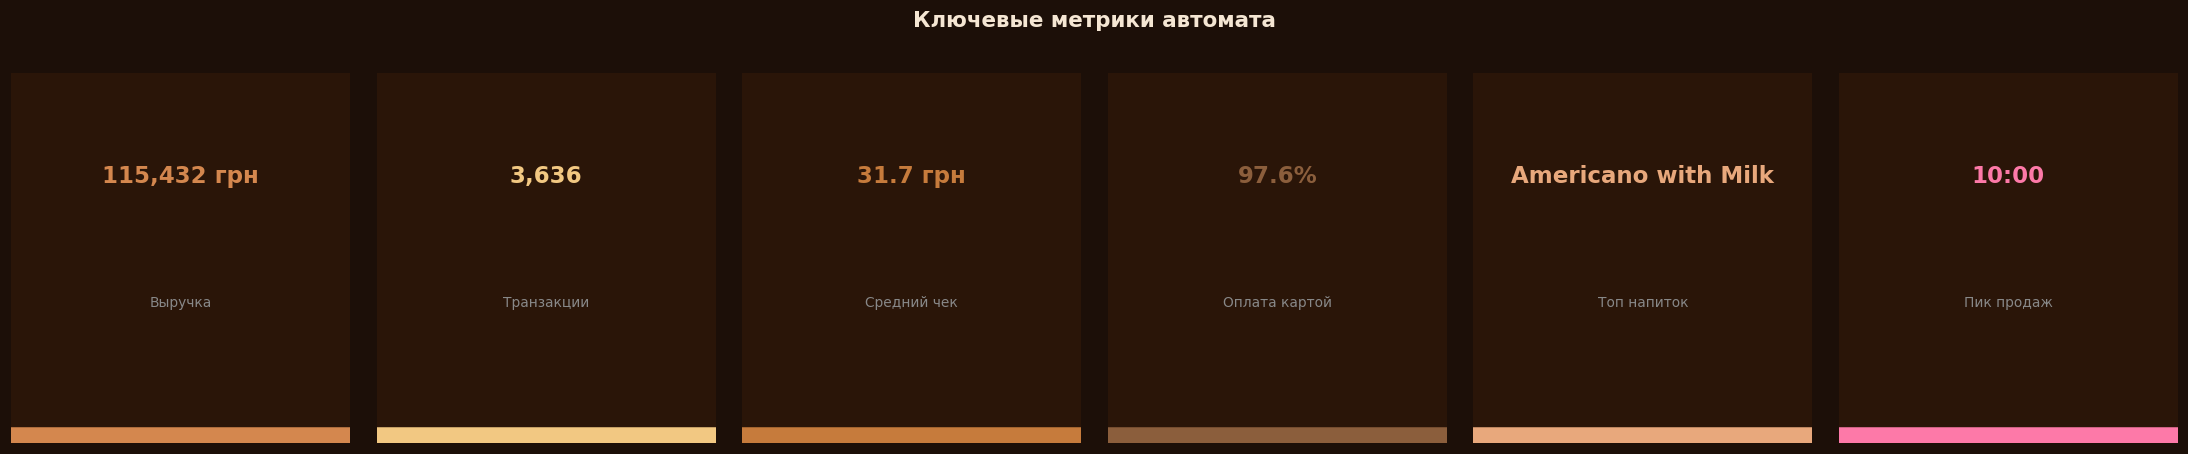

In [6]:
total_rev    = df['money'].sum()
total_txn    = len(df)
avg_check    = df['money'].mean()
card_pct     = (df['cash_type'] == 'card').mean() * 100
top_drink    = df['coffee_name'].value_counts().index[0]
peak_hour    = df['hour'].value_counts().index[0]

fig, axes = plt.subplots(1, 6, figsize=(20, 4))
fig.patch.set_facecolor(BG)

kpis = [
    ('Выручка',       f'{total_rev:,.0f} грн', ACCENT),
    ('Транзакции',    f'{total_txn:,}',         ACCENT2),
    ('Средний чек',   f'{avg_check:.1f} грн',   ACCENT3),
    ('Оплата картой', f'{card_pct:.1f}%',        ACCENT4),
    ('Топ напиток',   top_drink,                 ACCENT5),
    ('Пик продаж',    f'{peak_hour}:00',         '#fd79a8'),
]

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor(PANEL)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0,0),1,1, color=PANEL, zorder=0))
    ax.add_patch(plt.Rectangle((0,0),1,0.04, color=color, zorder=1))
    ax.text(0.5, 0.72, value,  ha='center', va='center', fontsize=15,
            fontweight='bold', color=color)
    ax.text(0.5, 0.38, label,  ha='center', va='center', fontsize=9,
            color='#888888')
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID)

fig.suptitle('Ключевые метрики автомата', fontsize=14, fontweight='bold',
             color=TEXT, y=1.02)
plt.tight_layout()
plt.show()

## 📈 2. Динамика выручки по месяцам
> Смотрим на тренд, растёт ли бизнес со временем?

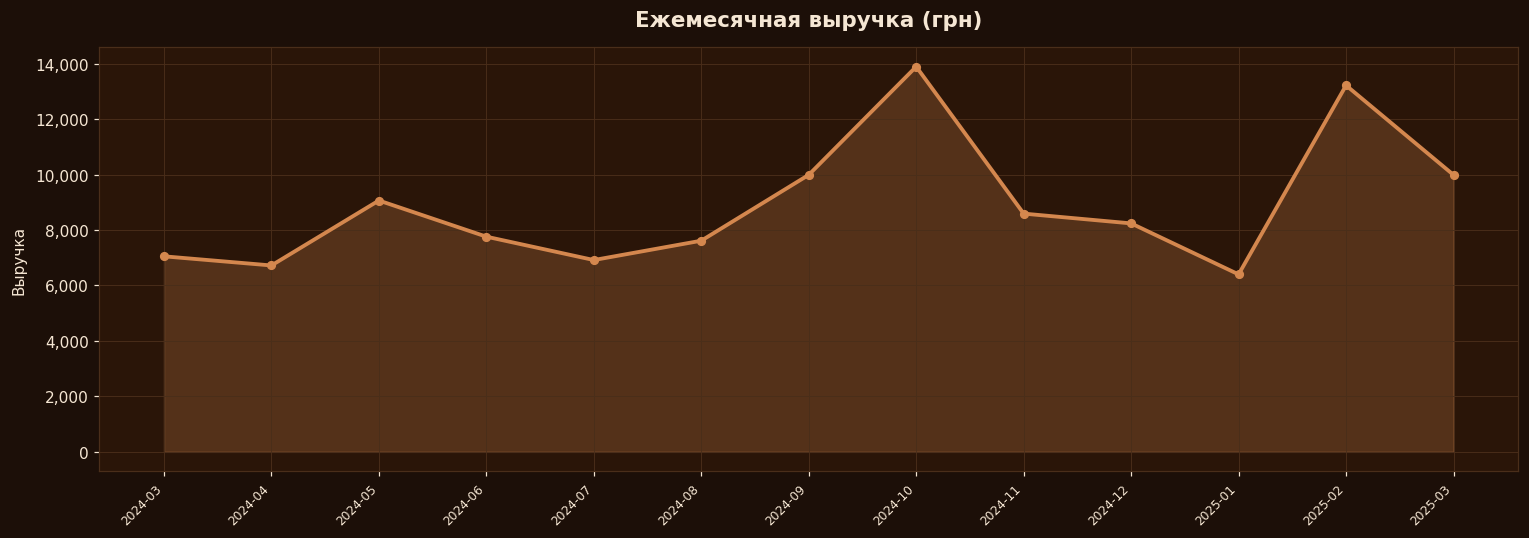

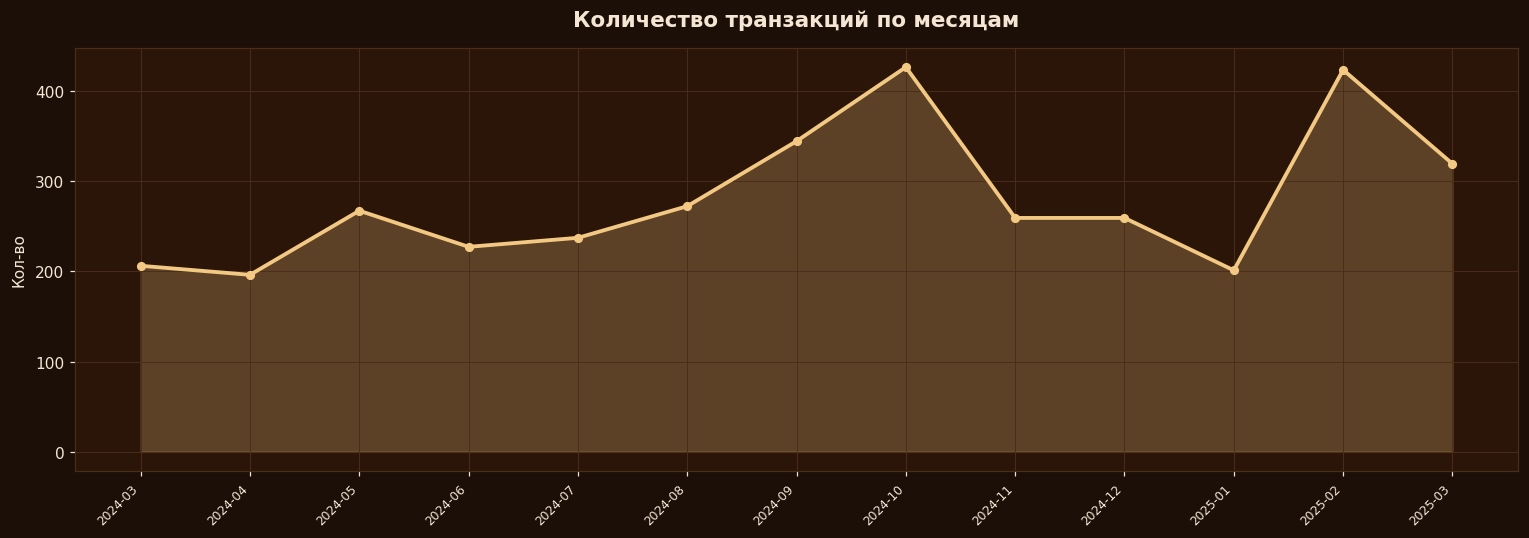

In [8]:
monthly = df.groupby('month').agg(
    revenue=('money', 'sum'),
    transactions=('money', 'count')
).reset_index()

# Выручка по месяцам
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax1.fill_between(range(len(monthly)), monthly['revenue'],
                 alpha=0.25, color=ACCENT)
ax1.plot(range(len(monthly)), monthly['revenue'],
         color=ACCENT, linewidth=2.5, marker='o', markersize=5)
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['month'], rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
style_ax(ax1, 'Ежемесячная выручка (грн)', ylabel='Выручка')
plt.tight_layout()
plt.show()

# Транзакции по месяцам 
fig, ax2 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor(BG)
ax2.fill_between(range(len(monthly)), monthly['transactions'],
                 alpha=0.25, color=ACCENT2)
ax2.plot(range(len(monthly)), monthly['transactions'],
         color=ACCENT2, linewidth=2.5, marker='o', markersize=5)
ax2.set_xticks(range(len(monthly)))
ax2.set_xticklabels(monthly['month'], rotation=45, ha='right', fontsize=8)
style_ax(ax2, 'Количество транзакций по месяцам', ylabel='Кол-во')
plt.tight_layout()
plt.show()


## ☕ 3. Популярность напитков
> Что заказывают чаще всего? Какие напитки приносят больше денег?

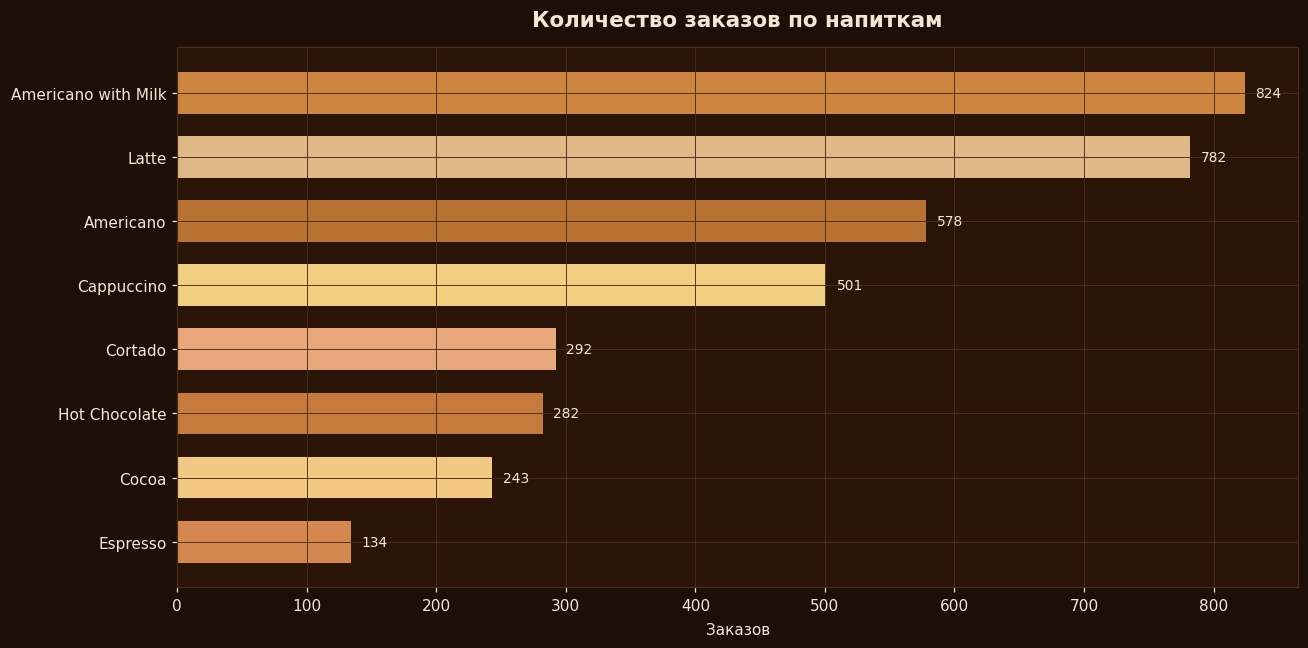

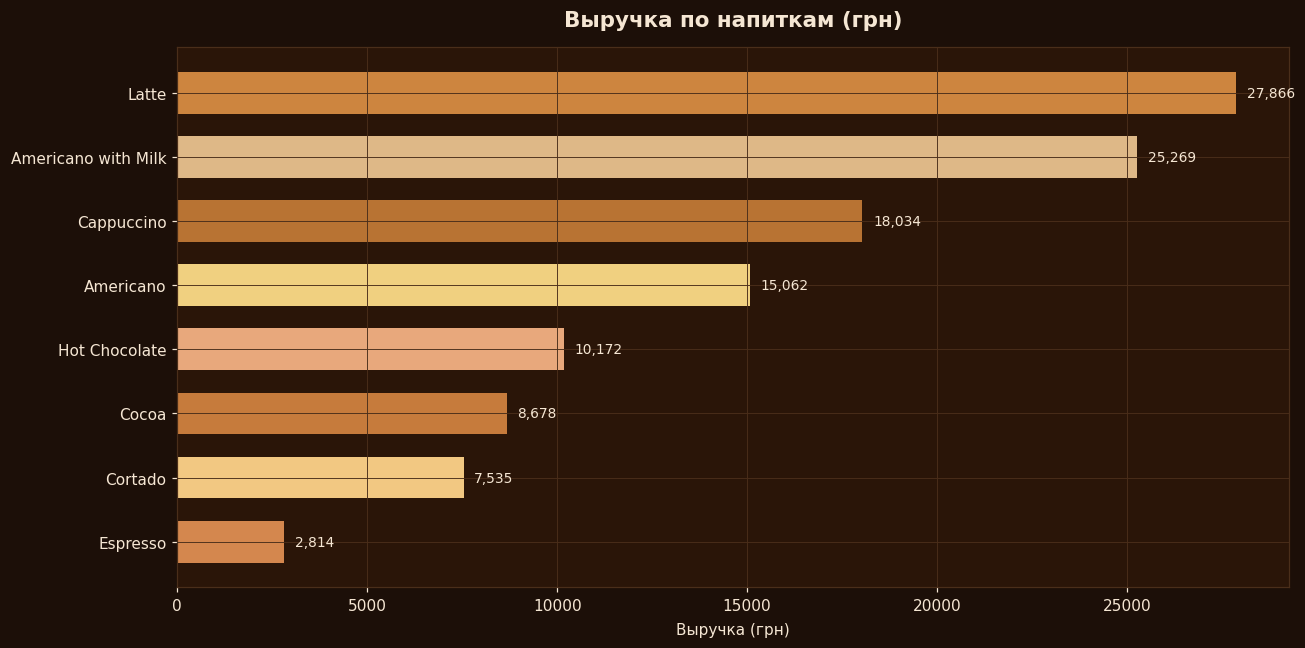

In [10]:
drink_stats = df.groupby('coffee_name').agg(
    count=('money', 'count'),
    revenue=('money', 'sum'),
    avg_price=('money', 'mean')
).sort_values('count', ascending=True)

# Количество заказов
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
colors_bar = [PALETTE[i % len(PALETTE)] for i in range(len(drink_stats))]
bars = ax1.barh(drink_stats.index, drink_stats['count'],
                color=colors_bar, edgecolor='none', height=0.65)
for bar, val in zip(bars, drink_stats['count']):
    ax1.text(bar.get_width() + drink_stats['count'].max()*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9, color=TEXT)
style_ax(ax1, 'Количество заказов по напиткам', xlabel='Заказов')
plt.tight_layout()
plt.show()

# Выручка по напиткам 
drink_rev = df.groupby('coffee_name')['money'].sum().sort_values(ascending=True)
fig, ax2 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
colors_rev = [PALETTE[i % len(PALETTE)] for i in range(len(drink_rev))]
bars2 = ax2.barh(drink_rev.index, drink_rev.values,
                 color=colors_rev, edgecolor='none', height=0.65)
for bar, val in zip(bars2, drink_rev.values):
    ax2.text(bar.get_width() + drink_rev.max()*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=9, color=TEXT)
style_ax(ax2, 'Выручка по напиткам (грн)', xlabel='Выручка (грн)')
plt.tight_layout()
plt.show()


## 🕐 4. Тепловая карта, когда покупают кофе?
> Час/День недели. Ищем пиковое время для оптимизации загрузки автомата.

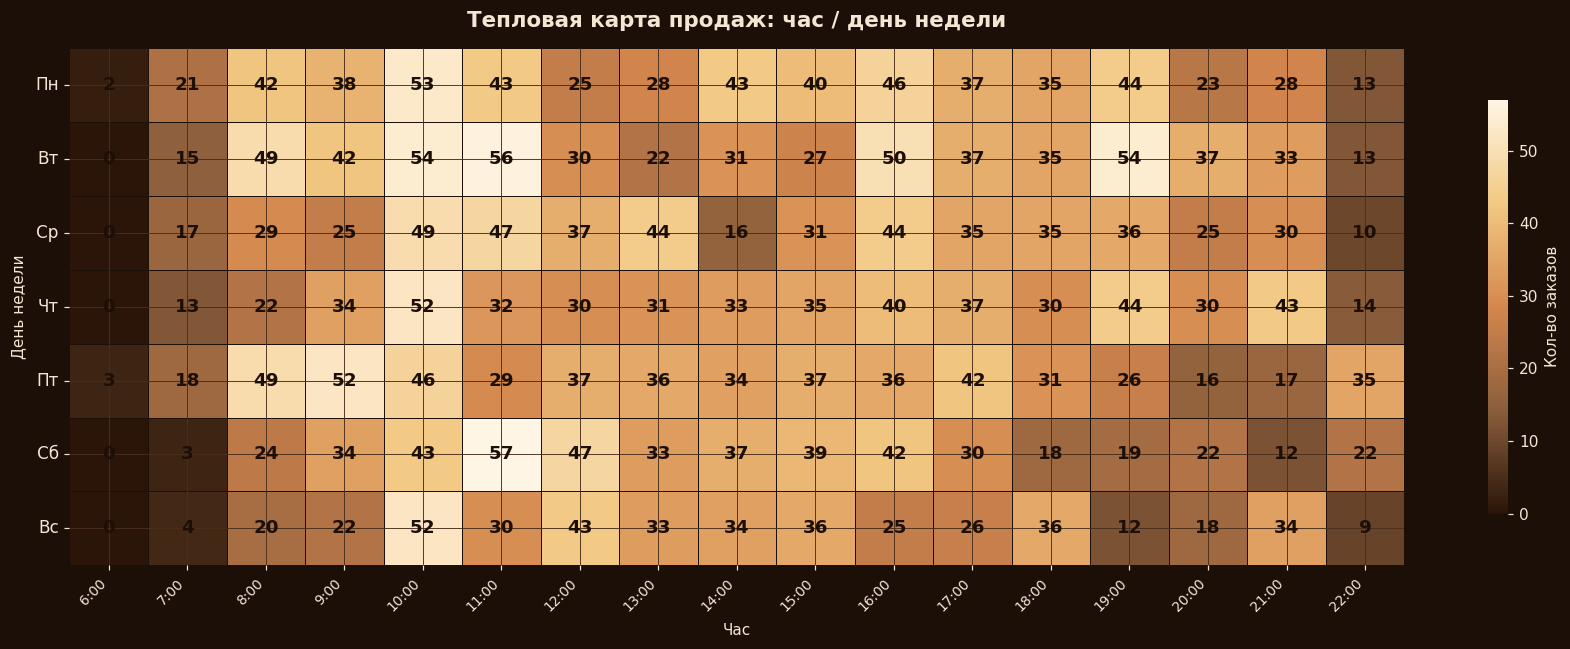

In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_ru    = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

heatmap_data = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(
    [d for d in day_order if d in heatmap_data.index]
)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor(BG)

# colormap 
from matplotlib.colors import LinearSegmentedColormap
coffee_cmap = LinearSegmentedColormap.from_list(
    'coffee', ['#2A1508', '#8B5E3C', '#D4874E', '#F2C882', '#FFF5E4']
)

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap=coffee_cmap,
    linewidths=0.4,
    linecolor=BG,
    annot=True,
    fmt='d',
    annot_kws={'size': 12, 'color': '#1C0F08', 'fontweight': 'bold'},
    cbar_kws={'label': 'Кол-во заказов', 'shrink': 0.8}
)

ru_labels = [day_ru[day_order.index(d)]
             for d in heatmap_data.index if d in day_order]
ax.set_yticklabels(ru_labels, rotation=0, fontsize=11)
ax.set_xticklabels([f'{h}:00' for h in heatmap_data.columns],
                   rotation=45, ha='right', fontsize=9)
style_ax(ax, 'Тепловая карта продаж: час / день недели',
         xlabel='Час', ylabel='День недели')
ax.set_facecolor(PANEL)

# цвет colorbar labels
ax.collections[0].colorbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(ax.collections[0].colorbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax.collections[0].colorbar.set_label('Кол-во заказов', color=TEXT)

plt.tight_layout()
plt.show()


## 💳 5. Наличные vs Карта
> Как платят клиенты? Динамика по месяцам.

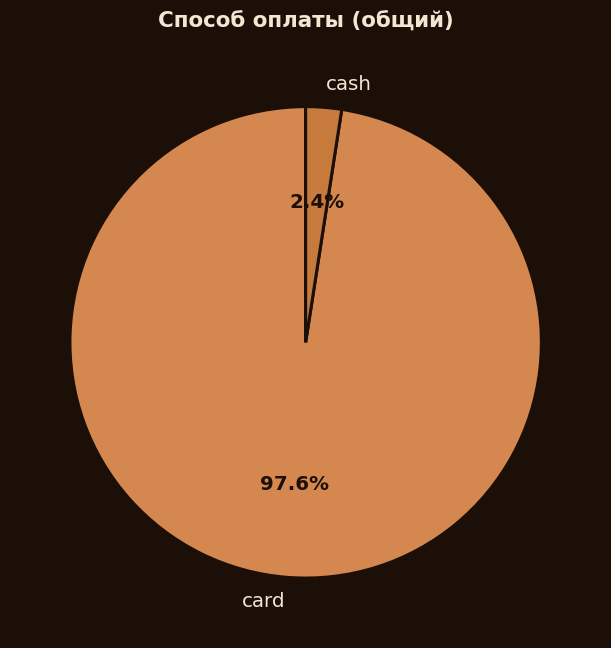

In [14]:
payment_month = df.groupby(['month','cash_type']).size().unstack(fill_value=0)
payment_month['total'] = payment_month.sum(axis=1)
for col in ['card','cash']:
    if col in payment_month.columns:
        payment_month[f'{col}_pct'] = payment_month[col] / payment_month['total'] * 100

# Пайчарт общий
payment_total = df['cash_type'].value_counts()
fig, ax1 = plt.subplots(figsize=(6, 6))
fig.patch.set_facecolor(BG)
ax1.set_facecolor(PANEL)
wedge_props = {'linewidth': 2, 'edgecolor': BG}
wedges, texts, autotexts = ax1.pie(
    payment_total.values,
    labels=payment_total.index,
    colors=[ACCENT, ACCENT3],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=wedge_props,
    textprops={'color': TEXT, 'fontsize': 13}
)
for at in autotexts:
    at.set_color('#1C0F08')
    at.set_fontweight('bold')
style_ax(ax1, 'Способ оплаты (общий)')
plt.tight_layout()
plt.show()



## 👥 6. Анализ постоянных клиентов
> Кто чаще всего покупает? Сколько приносят топ-клиенты?

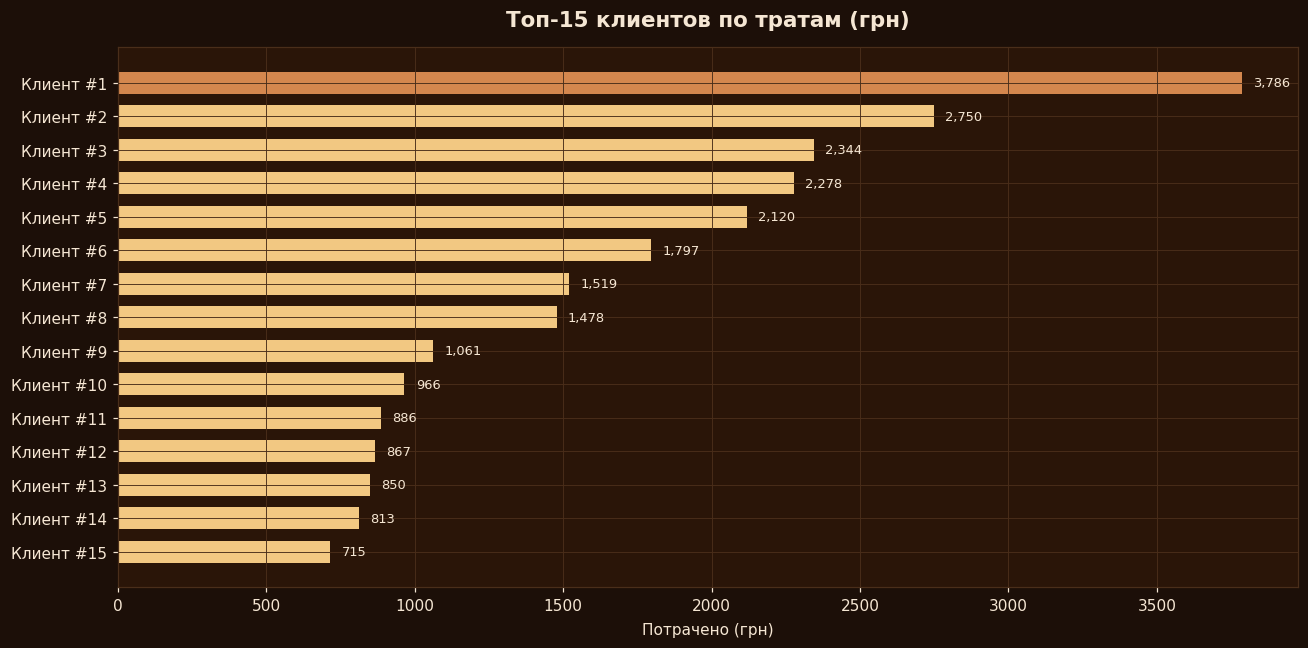

In [16]:
card_df = df[df['cash_type'] == 'card'].copy()
top_clients = card_df.groupby('card').agg(
    visits=('money','count'),
    total_spent=('money','sum'),
    avg_check=('money','mean'),
    fav_drink=('coffee_name', lambda x: x.value_counts().index[0])
).sort_values('total_spent', ascending=False).head(15)

top_clients.index = [f'Клиент #{i+1}' for i in range(len(top_clients))]

# Топ 15 по тратам 
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
colors_c = [ACCENT if i == 0 else ACCENT2 for i in range(len(top_clients))]
bars = ax1.barh(top_clients.index[::-1], top_clients['total_spent'][::-1],
                color=colors_c[::-1], edgecolor='none', height=0.65)
for bar, val in zip(bars, top_clients['total_spent'][::-1]):
    ax1.text(bar.get_width() + top_clients['total_spent'].max()*0.01,
             bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', fontsize=8.5, color=TEXT)
style_ax(ax1, 'Топ-15 клиентов по тратам (грн)', xlabel='Потрачено (грн)')
plt.tight_layout()
plt.show()



## 📉 7. Средний чек по напиткам и дням недели
> Где самая высокая маржинальность? Когда люди тратят больше?

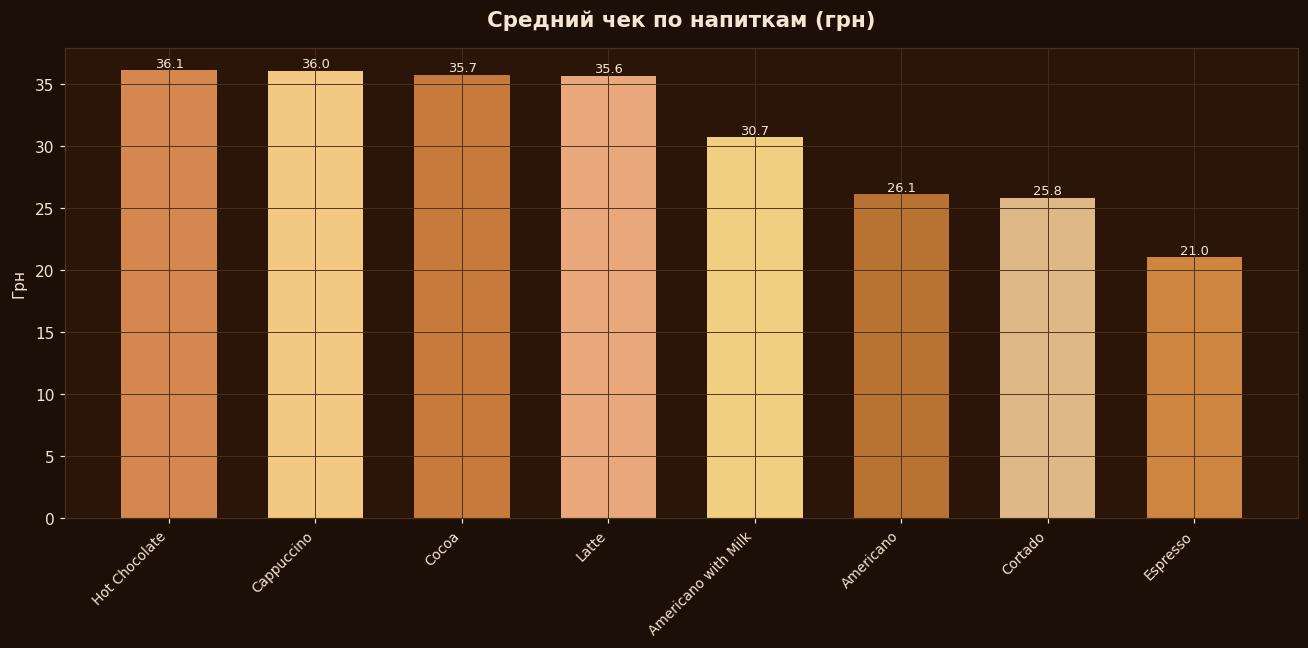

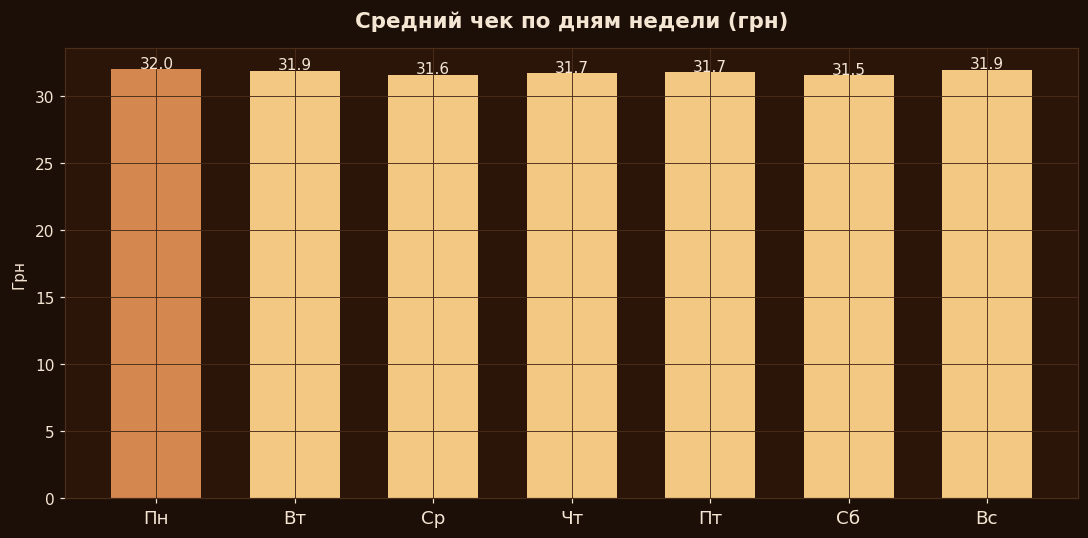

In [18]:
#  Средний чек по напиткам 
avg_by_drink = df.groupby('coffee_name')['money'].mean().sort_values(ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
bars = ax1.bar(range(len(avg_by_drink)), avg_by_drink.values,
               color=PALETTE[:len(avg_by_drink)], edgecolor='none', width=0.65)
ax1.set_xticks(range(len(avg_by_drink)))
# Исправлено: rotation=45 + ha='right' чтобы подписи не налезали друг на друга
ax1.set_xticklabels(avg_by_drink.index, rotation=45, ha='right', fontsize=9)
for bar, val in zip(bars, avg_by_drink.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=8.5, color=TEXT)
style_ax(ax1, 'Средний чек по напиткам (грн)', ylabel='Грн')
plt.tight_layout()
plt.show()

#  Средний чек по дням недели 
avg_by_day = df.groupby('weekday_n').agg(
    avg=('money','mean'),
    weekday=('weekday', 'first')
).sort_index()
day_labels_ru = ['Пн','Вт','Ср','Чт','Пт','Сб','Вс']

fig, ax2 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
bar_colors = [ACCENT if v == avg_by_day['avg'].max() else ACCENT2
              for v in avg_by_day['avg']]
bars2 = ax2.bar(range(len(avg_by_day)), avg_by_day['avg'],
                color=bar_colors, edgecolor='none', width=0.65)
ax2.set_xticks(range(len(avg_by_day)))
ax2.set_xticklabels(
    [day_labels_ru[i] for i in avg_by_day.index],
    fontsize=12
)
for bar, val in zip(bars2, avg_by_day['avg']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontsize=10, color=TEXT)
style_ax(ax2, 'Средний чек по дням недели (грн)', ylabel='Грн')
plt.tight_layout()
plt.show()


## 🔁 8. Retention: как часто возвращаются клиенты?
> Считаем среднее количество дней между визитами для каждого клиента.

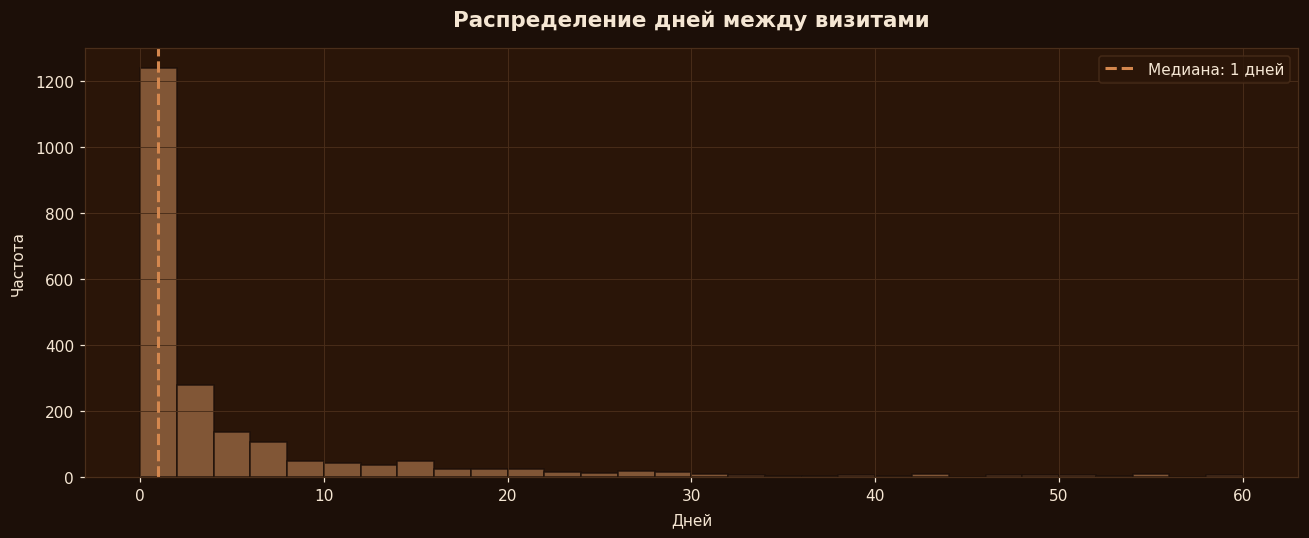

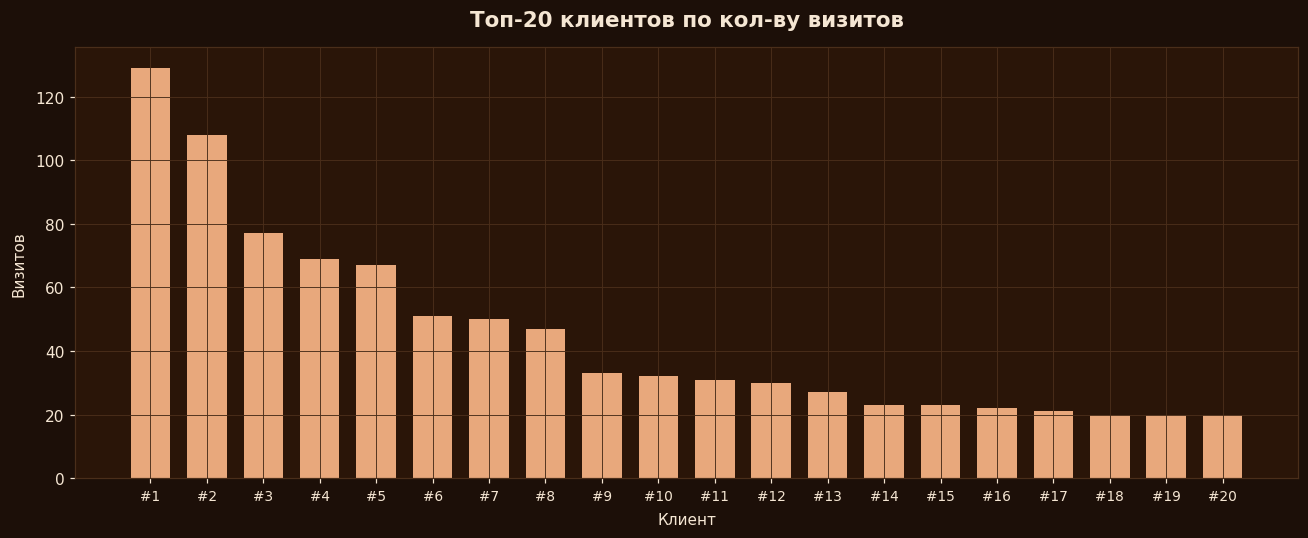

📌 Медианный интервал между визитами: 1 дней
📌 Среднее: 4.9 дней


In [20]:
card_sorted = card_df.sort_values(['card','datetime'])
card_sorted['prev_visit'] = card_sorted.groupby('card')['datetime'].shift(1)
card_sorted['days_between'] = (
    card_sorted['datetime'] - card_sorted['prev_visit']
).dt.days

retention = card_sorted.dropna(subset=['days_between'])
retention = retention[retention['days_between'] <= 60]  # убираем выбросы

# Распределение дней между визитами 
fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax1.hist(retention['days_between'], bins=30,
         color=ACCENT4, edgecolor=BG, alpha=0.9)
ax1.axvline(retention['days_between'].median(), color=ACCENT,
            linestyle='--', linewidth=2,
            label=f'Медиана: {retention["days_between"].median():.0f} дней')
ax1.legend()
style_ax(ax1, 'Распределение дней между визитами',
         xlabel='Дней', ylabel='Частота')
plt.tight_layout()
plt.show()

# Топ 20 по частоте визитов
visit_freq = card_df.groupby('card').size().sort_values(ascending=False).head(20)
visit_freq.index = [f'#{i+1}' for i in range(len(visit_freq))]

fig, ax2 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor(BG)
ax2.bar(visit_freq.index, visit_freq.values,
        color=ACCENT5, edgecolor='none', width=0.7)
style_ax(ax2, 'Топ-20 клиентов по кол-ву визитов',
         xlabel='Клиент', ylabel='Визитов')
ax2.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.show()

print(f'📌 Медианный интервал между визитами: {retention["days_between"].median():.0f} дней')
print(f'📌 Среднее: {retention["days_between"].mean():.1f} дней')


## 📋 9. Итоговые выводы и рекомендации
> На основе данных, что реально можно улучшить?

In [22]:
print('='*60)
print('📋 БИЗНЕС-ВЫВОДЫ')
print('='*60)

peak_h = df['hour'].value_counts().index[0]
peak_day = df['weekday'].value_counts().index[0]
top3_drinks = df['coffee_name'].value_counts().head(3).index.tolist()
low_drinks = df['coffee_name'].value_counts().tail(3).index.tolist()
card_share = (df['cash_type']=='card').mean()*100

print(f"""
⏰ Пиковое время продаж   : {peak_h}:00
📅 Самый активный день   : {peak_day}
☕ Топ-3 напитка          : {', '.join(top3_drinks)}
📉 Наименее популярные   : {', '.join(low_drinks)}
💳 Доля оплаты картой    : {card_share:.1f}%

💡 Рекомендации:
   1. Убедиться что автомат заправлен к {peak_h}:00, пик трафика
   2. Рассмотреть акции на {', '.join(low_drinks)} для увеличения их продаж
   3. {card_share:.0f}% оплат картой, автомат хорошо принимает безнал
   4. Топ напитки ({top3_drinks[0]}, {top3_drinks[1]}), держать в приоритете по запасам
""")

📋 БИЗНЕС-ВЫВОДЫ

⏰ Пиковое время продаж   : 10:00
📅 Самый активный день   : Tuesday
☕ Топ-3 напитка          : Americano with Milk, Latte, Americano
📉 Наименее популярные   : Hot Chocolate, Cocoa, Espresso
💳 Доля оплаты картой    : 97.6%

💡 Рекомендации:
   1. Убедиться что автомат заправлен к 10:00, пик трафика
   2. Рассмотреть акции на Hot Chocolate, Cocoa, Espresso для увеличения их продаж
   3. 98% оплат картой, автомат хорошо принимает безнал
   4. Топ напитки (Americano with Milk, Latte), держать в приоритете по запасам

